In [ ]:
from scipy.integrate import odeint
from scipy.integrate import solve_ivp
import numpy as np
import matplotlib.pyplot as plt

!pip install ddeint

from ddeint import ddeint

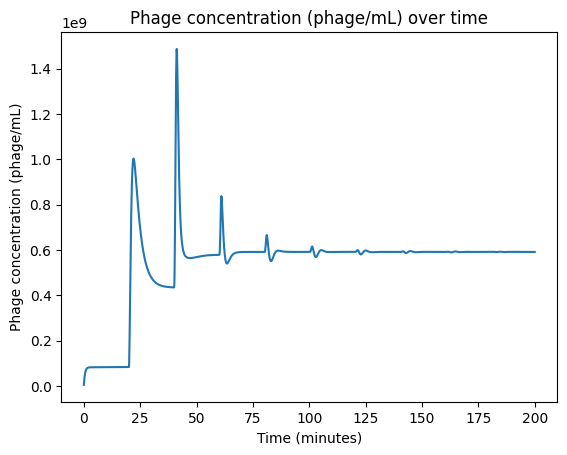

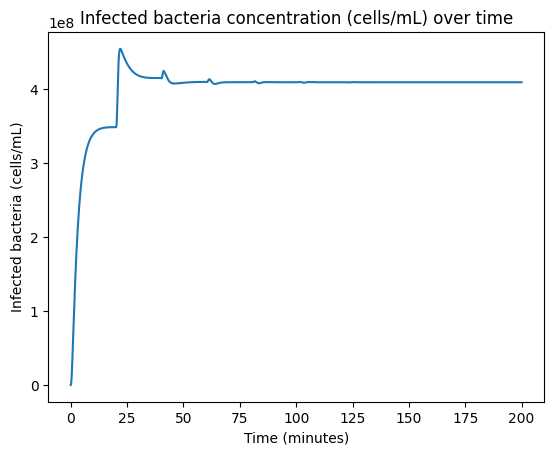

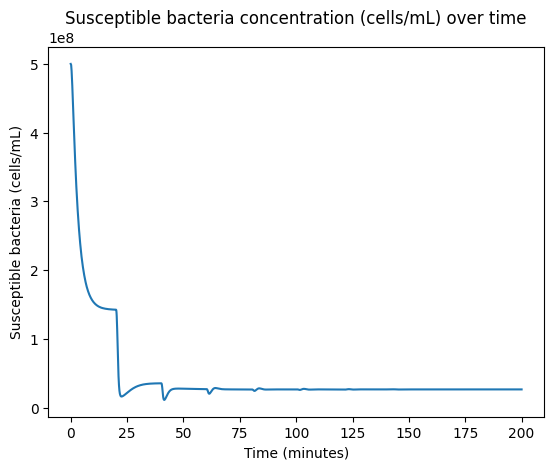

In [ ]:

import numpy as np
import matplotlib.pyplot as plt

!pip install ddeint

from ddeint import ddeint
def equation(Y, t, d=20):
    bc= 5E8; # constant bacteria concentration cells/L
    d = 20; #time delay used
    tau = 20; #latent time (mins)

    # Kinetic Parameters
    w = 0.1; # washout rate [ml/min];
    beta = 130; # burst size [phages/cell]
    gamma = 3E-9; # adsorption rate constant [ml/min*phage]
    e=np.exp(1)
    u, p, i = Y(t)
    ud,pd, id = Y(t-d) #time delay variables
    dU_dt = -u*w+bc*w-gamma*p*u;

    dP_dt = -p*w-gamma*p*u-gamma*p*i+beta*gamma*ud*pd*e**(-w*tau)

    dI_dt = -i*w+gamma*p*u-gamma*ud*pd*e**(-w*tau)

    return [dU_dt, dP_dt, dI_dt]

def initial_history_func(t):
    return [5E8, 5E6, 0]

ts = np.linspace(0, 200, 2000)

ys = ddeint(equation, initial_history_func, ts)

u_sol =ys[:,0]
p_sol =ys[:,1]
i_sol =ys[:,2]

fig,ax = plt.subplots( )
ax.set(title = "Phage concentration (phage/mL) over time",
       xlabel = "Time (minutes)",
       ylabel = "Phage concentration (phage/mL)")

ax.plot(ts,p_sol)

fig,ax = plt.subplots( )
ax.set(title = "Infected bacteria concentration (cells/mL) over time",
       xlabel = "Time (minutes)",
       ylabel = "Infected bacteria (cells/mL)")
ax.plot(ts,i_sol)

fig,ax = plt.subplots( )
ax.set(title = "Susceptible bacteria concentration (cells/mL) over time",
       xlabel = "Time (minutes)",
       ylabel = "Susceptible bacteria (cells/mL)")
ax.plot(ts,u_sol)



In [ ]:

def get_steady_state_values(beta = 130, gamma = 3E-9, tau = 20 ):
  # calculating steady state:
  bc= 5E8; # constant bacteria concentration cells/mL


  # Kinetic Parameters
  w = 0.1; # washout rate [ml/min];

  e=np.exp(1)
  num= bc*((beta*e**(-w*tau))-1)-(w/gamma)
  denom = bc*(1-(e**(-w*tau)))+(w/gamma)
  p= (w/gamma)*(num/denom)

  u = denom/(e**(-w*tau)*(beta-1))
  i = num*((e**(w*tau)-1)/(beta-1))

  return p, u , i

get_steady_state_values()

(591515918.2554708, 26673100.15061767, 409269069.7947583)

[35490955095328.24, 44209781861683.64, 55834884216824.19, 84897640104675.55, 143023151880378.25]


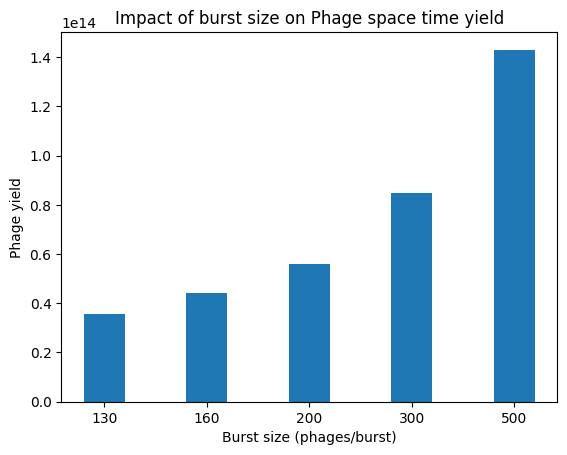

In [ ]:
p_b=[]
b=[130, 160, 200, 300, 500]
for beta in b:
  s = get_steady_state_values(beta = beta)
  p_b.append(s[0]*1000*60)

print (p_b)

plt.bar(['130', '160', '200', '300', '500'],p_b, width =0.4)
# plt.xticks(b, ('130', '160', '200', '300', '500'))
plt.xlabel("Burst size (phages/burst)")
plt.ylabel("Phage yield")
plt.title("Impact of burst size on Phage space time yield")
plt.show()


394410799.7972452
409269069.7947583
410754896.79450965
410903479.4944848


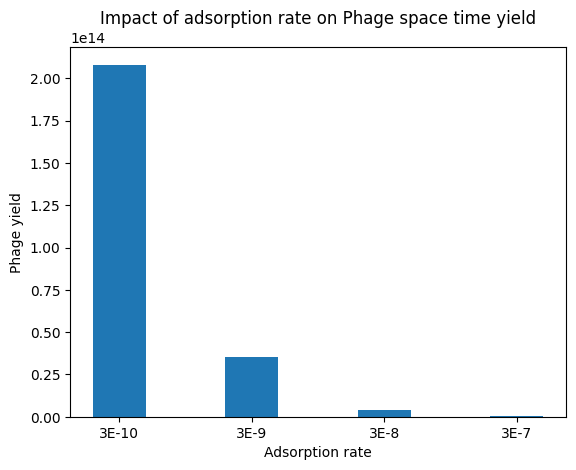

[208014023958916.3, 35490955095328.24, 3807258746677.4062, 383504411646.8062]


In [ ]:
p_g=[]
g=[3E-10,3E-9, 3E-8, 3E-7]
for gamma in g:
  s = get_steady_state_values( gamma = gamma)
  p_g.append(s[0]*1000*60)
  print(s[2])

plt.bar(['3E-10','3E-9', '3E-8', '3E-7'],p_g, width =0.4)
# plt.xticks(b, ('130', '160', '200', '300', '500'))
plt.xlabel("Adsorption rate")
plt.ylabel("Phage yield")
plt.title("Impact of adsorption rate on Phage space time yield")
plt.show()

print (p_g)

In [ ]:
p_t=[]
t=[20, 17.5, 15]
for tau in t:
  s = get_steady_state_values( tau = tau)
  p_t.append(s[0]*1000*60)

print (p_t)

[35490955095328.24, 48211717762378.94, 66245512640477.9]
